# 📈 Feature Analysis & Selection

**Mục tiêu:**
1. Phân tích thống kê: Cohen's d, KS, T-test
2. Auto-detect collinearity (r > 0.9)
3. **Select best features** (giữ sin/cos pairs)
4. **Save final_data.csv** với features đã chọn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded!")

Libraries loaded!


## 1. Load Data

In [2]:
# Paths
BASE_DIR = Path("..").resolve().parent
DATA_DIR = BASE_DIR / "data" / "preprocessed"
OUTPUT_ANALYSIS_DIR = BASE_DIR / "data" / "analysis"
OUTPUT_FIGURES_DIR = BASE_DIR / "data" / "figures"

# Create output directories
OUTPUT_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load processed data
df = pd.read_csv(DATA_DIR / "preprocessed_data.csv")
print(f"Loaded: {len(df)} rows, {len(df.columns)} columns")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Loaded: 4736 rows, 66 columns

Label distribution:
label
0    3929
1     807
Name: count, dtype: int64


In [3]:
# Get feature columns
feature_cols = [col for col in df.columns if col.startswith('feat_')]
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Total features: {len(feature_cols)}")
print(f"Numeric features: {len(numeric_features)}")

# Separate by label
df_real = df[df['label'] == 0]
df_fake = df[df['label'] == 1]
print(f"\nReal: {len(df_real)}, Fake: {len(df_fake)}")

Total features: 40
Numeric features: 40

Real: 3929, Fake: 807


## 2. Statistical Analysis

In [4]:
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    if pooled_std == 0:
        return 0
    return (group1.mean() - group2.mean()) / pooled_std

def interpret_d(d):
    """Interpret Cohen's d"""
    d = abs(d)
    if d < 0.2: return "negligible"
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else: return "large"

In [5]:
# Calculate statistics for all features
results = []

for feat in numeric_features:
    real_vals = df_real[feat].dropna()
    fake_vals = df_fake[feat].dropna()
    
    d = cohens_d(fake_vals, real_vals)
    ks_stat, ks_pval = stats.ks_2samp(real_vals, fake_vals)
    t_stat, t_pval = stats.ttest_ind(real_vals, fake_vals, equal_var=False)
    
    results.append({
        'feature': feat,
        'mean_real': real_vals.mean(),
        'mean_fake': fake_vals.mean(),
        'cohens_d': d,
        'cohens_d_abs': abs(d),
        'effect_size': interpret_d(d),
        'ks_stat': ks_stat,
        't_pvalue': t_pval,
        'significant': t_pval < 0.05
    })

results_df = pd.DataFrame(results).sort_values('cohens_d_abs', ascending=False)
print(f"Analyzed {len(results_df)} features")

Analyzed 40 features


In [6]:
# Display results
display_df = results_df[['feature', 'mean_real', 'mean_fake', 'cohens_d', 'effect_size', 'ks_stat', 't_pvalue', 'significant']].copy()
display_df['mean_real'] = display_df['mean_real'].round(4)
display_df['mean_fake'] = display_df['mean_fake'].round(4)
display_df['cohens_d'] = display_df['cohens_d'].round(4)
display_df['ks_stat'] = display_df['ks_stat'].round(4)
display_df['t_pvalue'] = display_df['t_pvalue'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")

print("="*100)
print("FEATURE STATISTICS (sorted by |Cohen's d|)")
print("="*100)
display(display_df)

FEATURE STATISTICS (sorted by |Cohen's d|)


,feature,mean_real,mean_fake,cohens_d,effect_size,ks_stat,t_pvalue,significant
23,feat_like_ratio,0.7702,0.5710,-0.7475,medium,0.3188,1.11e-58,True
3,feat_num_exclamation,0.1945,0.7683,0.5584,medium,0.2231,1.95e-20,True
14,feat_avg_word_length,4.5101,4.1977,-0.4276,small,0.2456,1.11e-34,True
24,feat_comment_ratio,0.0868,0.1486,0.4235,small,0.2932,4.45e-22,True
36,feat_hour_sin,0.0903,-0.1740,-0.3947,small,0.1920,2.88e-24,True
4,feat_num_question,0.2051,0.6419,0.3922,small,0.1461,1.48e-11,True
35,feat_is_evening,0.1049,0.2169,0.3426,small,0.1120,5.41e-13,True
30,feat_fake_ratio,0.0093,0.0393,0.2825,small,0.0364,5.51e-06,True
8,feat_num_urls,0.4355,0.1908,-0.2309,small,0.1179,2.10e-12,True
12,feat_digit_ratio,0.0224,0.0165,-0.2253,small,0.1387,1.38e-10,True


## 3. Auto-Detect Collinearity

In [7]:
# Calculate correlation matrix
corr_matrix = df[numeric_features].corr()

# Find highly correlated pairs (|r| > 0.9)
CORR_THRESHOLD = 0.9

high_corr_pairs = []
for i in range(len(numeric_features)):
    for j in range(i+1, len(numeric_features)):
        feat1 = numeric_features[i]
        feat2 = numeric_features[j]
        r = corr_matrix.loc[feat1, feat2]
        if abs(r) > CORR_THRESHOLD:
            high_corr_pairs.append({
                'feature_1': feat1,
                'feature_2': feat2,
                'correlation': r,
                'd_feat1': results_df[results_df['feature'] == feat1]['cohens_d_abs'].values[0],
                'd_feat2': results_df[results_df['feature'] == feat2]['cohens_d_abs'].values[0]
            })

corr_df = pd.DataFrame(high_corr_pairs)
print(f"Found {len(corr_df)} highly correlated pairs (|r| > {CORR_THRESHOLD})")

Found 12 highly correlated pairs (|r| > 0.9)


In [8]:
# Display collinear pairs
if len(corr_df) > 0:
    print("\n" + "="*80)
    print("HIGHLY CORRELATED PAIRS")
    print("="*80)
    for _, row in corr_df.iterrows():
        print(f"\n• {row['feature_1']} ↔ {row['feature_2']}")
        print(f"  Correlation: r = {row['correlation']:.4f}")
        print(f"  |d| feat_1: {row['d_feat1']:.4f}")
        print(f"  |d| feat_2: {row['d_feat2']:.4f}")
        if row['d_feat1'] >= row['d_feat2']:
            print(f"  → KEEP: {row['feature_1']} (higher |d|)")
        else:
            print(f"  → KEEP: {row['feature_2']} (higher |d|)")
else:
    print("No highly correlated pairs found.")


HIGHLY CORRELATED PAIRS

• feat_num_chars ↔ feat_num_words
  Correlation: r = 0.9947
  |d| feat_1: 0.0548
  |d| feat_2: 0.0982
  → KEEP: feat_num_words (higher |d|)

• feat_num_chars ↔ feat_num_sentences
  Correlation: r = 0.9012
  |d| feat_1: 0.0548
  |d| feat_2: 0.2085
  → KEEP: feat_num_sentences (higher |d|)

• feat_num_chars ↔ feat_num_special_chars
  Correlation: r = 0.9841
  |d| feat_1: 0.0548
  |d| feat_2: 0.0164
  → KEEP: feat_num_chars (higher |d|)

• feat_num_chars ↔ feat_num_long_words
  Correlation: r = 0.9357
  |d| feat_1: 0.0548
  |d| feat_2: 0.0196
  → KEEP: feat_num_chars (higher |d|)

• feat_num_chars ↔ feat_num_short_words
  Correlation: r = 0.9763
  |d| feat_1: 0.0548
  |d| feat_2: 0.1495
  → KEEP: feat_num_short_words (higher |d|)

• feat_num_words ↔ feat_num_sentences
  Correlation: r = 0.9205
  |d| feat_1: 0.0982
  |d| feat_2: 0.2085
  → KEEP: feat_num_sentences (higher |d|)

• feat_num_words ↔ feat_num_special_chars
  Correlation: r = 0.9702
  |d| feat_1: 0.098

## 4. Visualizations

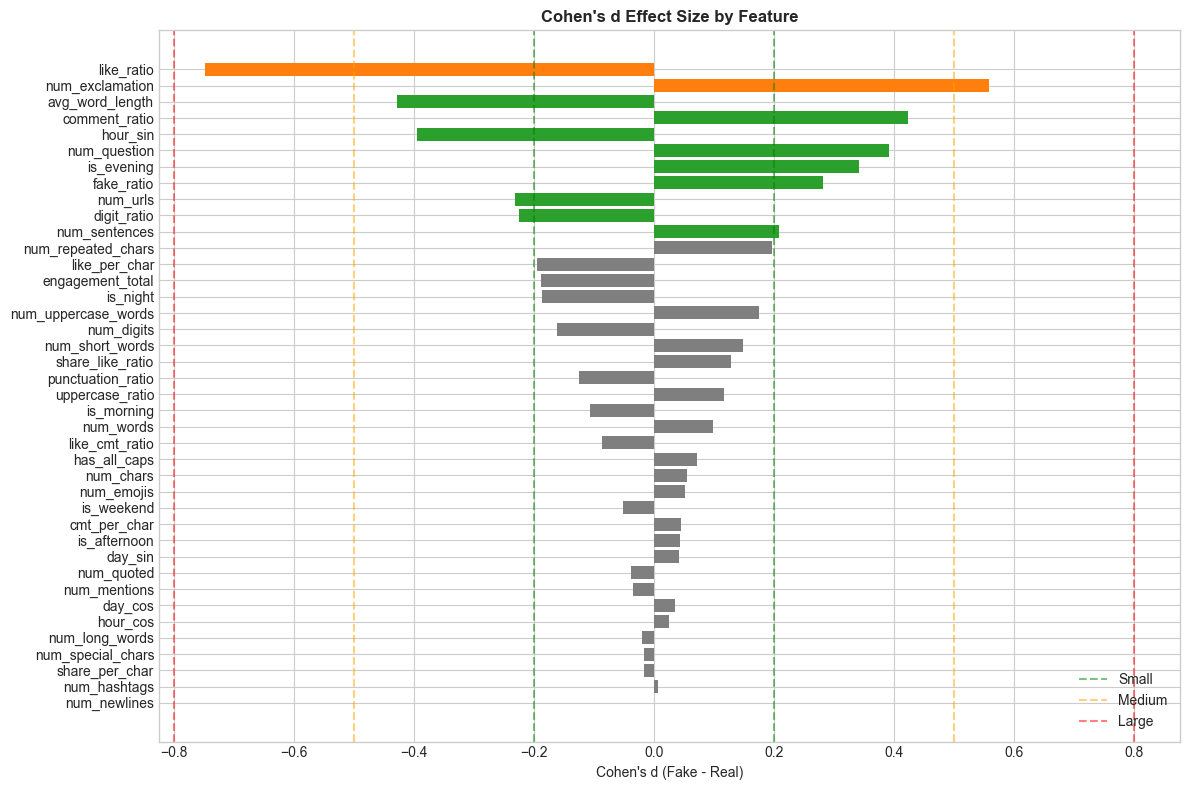

In [9]:
# Cohen's d bar chart
fig, ax = plt.subplots(figsize=(12, 8))

plot_df = results_df.sort_values('cohens_d_abs', ascending=True)
colors = ['#d62728' if d >= 0.8 else '#ff7f0e' if d >= 0.5 else '#2ca02c' if d >= 0.2 else '#7f7f7f' 
          for d in plot_df['cohens_d_abs']]

ax.barh(plot_df['feature'].str.replace('feat_', ''), plot_df['cohens_d'], color=colors)
ax.axvline(x=0.2, color='green', linestyle='--', alpha=0.5, label='Small')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large')
ax.axvline(x=-0.2, color='green', linestyle='--', alpha=0.5)
ax.axvline(x=-0.5, color='orange', linestyle='--', alpha=0.5)
ax.axvline(x=-0.8, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel("Cohen's d (Fake - Real)")
ax.set_title("Cohen's d Effect Size by Feature", fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'cohens_d_chart.png', dpi=150, bbox_inches='tight')
plt.show()

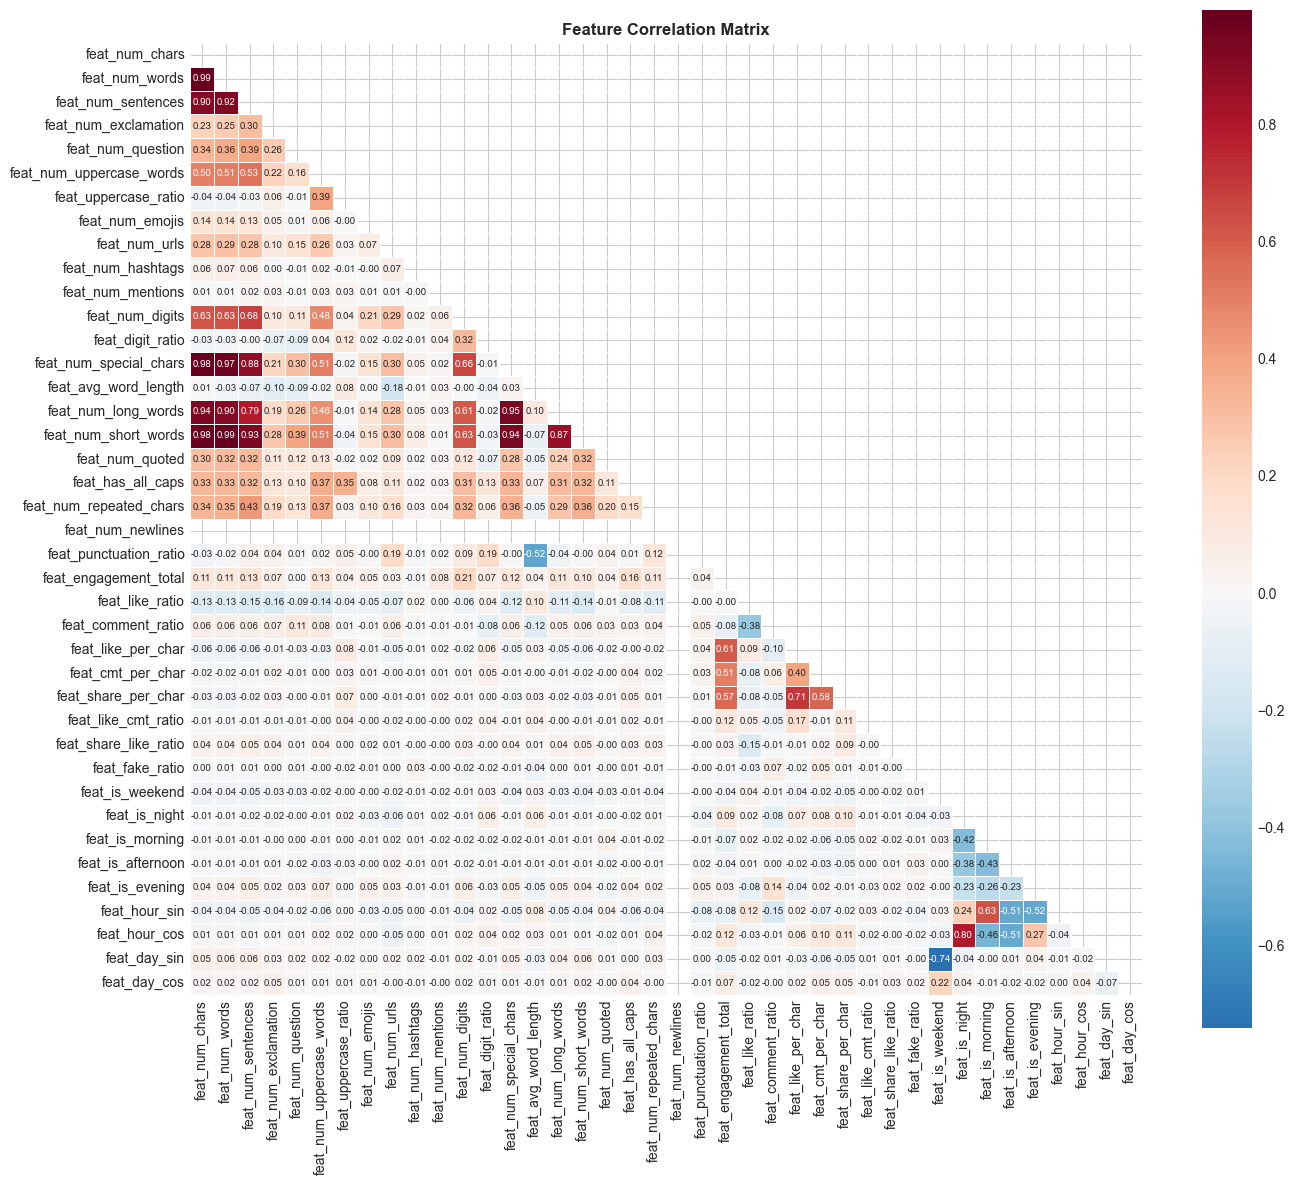

In [10]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5, annot_kws={'size': 7})
ax.set_title("Feature Correlation Matrix", fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. ⭐ Feature Selection

In [11]:
# Selection criteria
COHENS_D_MIN = 0.2  # Minimum effect size
P_VALUE_MAX = 0.05  # Maximum p-value

print(f"Selection criteria:")
print(f"  • |Cohen's d| >= {COHENS_D_MIN}")
print(f"  • p-value < {P_VALUE_MAX}")
print(f"  • Remove collinear features (keep higher |d|)")
print(f"  • Keep sin/cos pairs together")

Selection criteria:
  • |Cohen's d| >= 0.2
  • p-value < 0.05
  • Remove collinear features (keep higher |d|)
  • Keep sin/cos pairs together


In [12]:
def select_features(
    results_df: pd.DataFrame,
    corr_matrix: pd.DataFrame,
    min_d: float = 0.2,
    max_pval: float = 0.05,
    corr_threshold: float = 0.9
) -> list:
    """
    Select best features with auto-collinearity removal.
    Keep sin/cos pairs together.
    """
    # Step 1: Filter by effect size and significance
    candidates = results_df[
        (results_df['cohens_d_abs'] >= min_d) & 
        (results_df['t_pvalue'] < max_pval)
    ]['feature'].tolist()
    
    print(f"\n1. Candidates after d >= {min_d}, p < {max_pval}: {len(candidates)}")
    
    # Step 2: Remove collinear features (keep higher |d|)
    features_to_remove = set()
    
    for i, feat1 in enumerate(candidates):
        if feat1 in features_to_remove:
            continue
        for feat2 in candidates[i+1:]:
            if feat2 in features_to_remove:
                continue
            if feat1 not in corr_matrix.columns or feat2 not in corr_matrix.columns:
                continue
                
            r = abs(corr_matrix.loc[feat1, feat2])
            if r > corr_threshold:
                d1 = results_df[results_df['feature'] == feat1]['cohens_d_abs'].values[0]
                d2 = results_df[results_df['feature'] == feat2]['cohens_d_abs'].values[0]
                
                # Remove the one with lower |d|
                if d1 >= d2:
                    features_to_remove.add(feat2)
                    print(f"   Remove {feat2} (r={r:.3f} with {feat1}, |d|={d2:.3f} < {d1:.3f})")
                else:
                    features_to_remove.add(feat1)
                    print(f"   Remove {feat1} (r={r:.3f} with {feat2}, |d|={d1:.3f} < {d2:.3f})")
    
    selected = [f for f in candidates if f not in features_to_remove]
    print(f"\n2. After removing collinear: {len(selected)}")
    
    # Step 3: Ensure sin/cos pairs are together
    final_selected = set(selected)
    
    for feat in selected:
        if '_sin' in feat:
            cos_pair = feat.replace('_sin', '_cos')
            if cos_pair not in final_selected and cos_pair in results_df['feature'].values:
                final_selected.add(cos_pair)
                print(f"   Add {cos_pair} (pair of {feat})")
        elif '_cos' in feat:
            sin_pair = feat.replace('_cos', '_sin')
            if sin_pair not in final_selected and sin_pair in results_df['feature'].values:
                final_selected.add(sin_pair)
                print(f"   Add {sin_pair} (pair of {feat})")
    
    print(f"\n3. After ensuring sin/cos pairs: {len(final_selected)}")
    
    return sorted(list(final_selected))

In [13]:
# Select features
selected_features = select_features(
    results_df, 
    corr_matrix,
    min_d=COHENS_D_MIN,
    max_pval=P_VALUE_MAX,
    corr_threshold=CORR_THRESHOLD
)


1. Candidates after d >= 0.2, p < 0.05: 11

2. After removing collinear: 11
   Add feat_hour_cos (pair of feat_hour_sin)

3. After ensuring sin/cos pairs: 12


In [14]:
# Display selected features with stats
print("\n" + "="*70)
print(f"SELECTED FEATURES ({len(selected_features)})")
print("="*70)

selected_stats = results_df[results_df['feature'].isin(selected_features)].sort_values('cohens_d_abs', ascending=False)
for _, row in selected_stats.iterrows():
    print(f"  {row['feature']}: d={row['cohens_d']:.4f} ({row['effect_size']})")


SELECTED FEATURES (12)
  feat_like_ratio: d=-0.7475 (medium)
  feat_num_exclamation: d=0.5584 (medium)
  feat_avg_word_length: d=-0.4276 (small)
  feat_comment_ratio: d=0.4235 (small)
  feat_hour_sin: d=-0.3947 (small)
  feat_num_question: d=0.3922 (small)
  feat_is_evening: d=0.3426 (small)
  feat_fake_ratio: d=0.2825 (small)
  feat_num_urls: d=-0.2309 (small)
  feat_digit_ratio: d=-0.2253 (small)
  feat_num_sentences: d=0.2085 (small)
  feat_hour_cos: d=0.0255 (negligible)


## 6. Save Final Data

In [15]:
# Prepare final data with selected features
non_feature_cols = ['id', 'label', 'post_message', 'text_tfidf', 'text_bert', 'timestamp_post']
existing_non_feature_cols = [c for c in non_feature_cols if c in df.columns]

final_cols = existing_non_feature_cols + selected_features
df_final = df[final_cols].copy()

print(f"Final data shape: {df_final.shape}")
print(f"\nColumns ({len(df_final.columns)}):")
for col in df_final.columns:
    if col.startswith('feat_'):
        print(f"  ✓ {col}")
    else:
        print(f"  • {col}")

Final data shape: (4736, 18)

Columns (18):
  • id
  • label
  • post_message
  • text_tfidf
  • text_bert
  • timestamp_post
  ✓ feat_avg_word_length
  ✓ feat_comment_ratio
  ✓ feat_digit_ratio
  ✓ feat_fake_ratio
  ✓ feat_hour_cos
  ✓ feat_hour_sin
  ✓ feat_is_evening
  ✓ feat_like_ratio
  ✓ feat_num_exclamation
  ✓ feat_num_question
  ✓ feat_num_sentences
  ✓ feat_num_urls


In [16]:
# Save final data
final_output_path = DATA_DIR / "final_data.csv"
df_final.to_csv(final_output_path, index=False)

print(f"\n✅ Saved: {final_output_path}")
print(f"   Rows: {len(df_final)}")
print(f"   Columns: {len(df_final.columns)}")
print(f"   Features: {len(selected_features)}")


✅ Saved: D:\Vietnamese-Fake-News-Detection\data\preprocessed\final_data.csv
   Rows: 4736
   Columns: 18
   Features: 12


In [17]:
# Save analysis results
results_df.to_csv(OUTPUT_ANALYSIS_DIR / 'feature_statistics.csv', index=False)
print(f"✓ Saved: {OUTPUT_ANALYSIS_DIR / 'feature_statistics.csv'}")

# Save selected features list
with open(OUTPUT_ANALYSIS_DIR / 'selected_features.txt', 'w') as f:
    for feat in selected_features:
        f.write(feat + '\n')
print(f"✓ Saved: {OUTPUT_ANALYSIS_DIR / 'selected_features.txt'}")

✓ Saved: D:\Vietnamese-Fake-News-Detection\data\analysis\feature_statistics.csv
✓ Saved: D:\Vietnamese-Fake-News-Detection\data\analysis\selected_features.txt


## 7. Summary

In [18]:
print("="*70)
print("FEATURE ANALYSIS COMPLETE")
print("="*70)

print(f"\n📊 Total features analyzed: {len(numeric_features)}")

large_effect = results_df[results_df['cohens_d_abs'] >= 0.8]
medium_effect = results_df[(results_df['cohens_d_abs'] >= 0.5) & (results_df['cohens_d_abs'] < 0.8)]
small_effect = results_df[(results_df['cohens_d_abs'] >= 0.2) & (results_df['cohens_d_abs'] < 0.5)]

print(f"\n📈 Effect sizes:")
print(f"   Large (d≥0.8): {len(large_effect)}")
print(f"   Medium (0.5≤d<0.8): {len(medium_effect)}")
print(f"   Small (0.2≤d<0.5): {len(small_effect)}")

print(f"\n🔗 Collinear pairs detected: {len(corr_df)}")

print(f"\n✅ Selected features: {len(selected_features)}")
for feat in selected_features:
    d = results_df[results_df['feature'] == feat]['cohens_d'].values[0]
    print(f"   • {feat} (d={d:.3f})")

print(f"\n💾 Output files:")
print(f"   • {DATA_DIR / 'final_data.csv'}")
print(f"   • {OUTPUT_ANALYSIS_DIR / 'feature_statistics.csv'}")
print(f"   • {OUTPUT_ANALYSIS_DIR / 'selected_features.txt'}")
print(f"   • {OUTPUT_FIGURES_DIR / 'cohens_d_chart.png'}")
print(f"   • {OUTPUT_FIGURES_DIR / 'feature_correlation.png'}")

FEATURE ANALYSIS COMPLETE

📊 Total features analyzed: 40

📈 Effect sizes:
   Large (d≥0.8): 0
   Medium (0.5≤d<0.8): 2
   Small (0.2≤d<0.5): 9

🔗 Collinear pairs detected: 12

✅ Selected features: 12
   • feat_avg_word_length (d=-0.428)
   • feat_comment_ratio (d=0.423)
   • feat_digit_ratio (d=-0.225)
   • feat_fake_ratio (d=0.282)
   • feat_hour_cos (d=0.026)
   • feat_hour_sin (d=-0.395)
   • feat_is_evening (d=0.343)
   • feat_like_ratio (d=-0.748)
   • feat_num_exclamation (d=0.558)
   • feat_num_question (d=0.392)
   • feat_num_sentences (d=0.208)
   • feat_num_urls (d=-0.231)

💾 Output files:
   • D:\Vietnamese-Fake-News-Detection\data\preprocessed\final_data.csv
   • D:\Vietnamese-Fake-News-Detection\data\analysis\feature_statistics.csv
   • D:\Vietnamese-Fake-News-Detection\data\analysis\selected_features.txt
   • D:\Vietnamese-Fake-News-Detection\data\figures\cohens_d_chart.png
   • D:\Vietnamese-Fake-News-Detection\data\figures\feature_correlation.png


# 📈 Feature Analysis

Phân tích features sau preprocessing:
1. **Cohen's d** - Effect size
2. **KS Statistic** - Distribution difference
3. **T-test** - Statistical significance
4. **Correlation** - Feature redundancy

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries loaded!")

Libraries loaded!


## 1. Load Data

In [20]:
# Paths
BASE_DIR = Path("../..")
DATA_DIR = BASE_DIR / "data" / "preprocessed"
OUTPUT_ANALYSIS_DIR = BASE_DIR / "data" / "analysis"
OUTPUT_FIGURES_DIR = BASE_DIR / "data" / "figures"

# Create output directories
OUTPUT_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load processed data
df = pd.read_csv(DATA_DIR / "preprocessed_data.csv")
print(f"Loaded: {len(df)} rows, {len(df.columns)} columns")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Loaded: 4736 rows, 66 columns

Label distribution:
label
0    3929
1     807
Name: count, dtype: int64


In [21]:
# Get feature columns
feature_cols = [col for col in df.columns if col.startswith('feat_')]
numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Total features: {len(feature_cols)}")
print(f"Numeric features: {len(numeric_features)}")

# Separate by label
df_real = df[df['label'] == 0]
df_fake = df[df['label'] == 1]
print(f"\nReal: {len(df_real)}, Fake: {len(df_fake)}")

Total features: 40
Numeric features: 40

Real: 3929, Fake: 807


## 2. Statistical Analysis

In [22]:
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    if pooled_std == 0:
        return 0
    return (group1.mean() - group2.mean()) / pooled_std

def interpret_d(d):
    """Interpret Cohen's d"""
    d = abs(d)
    if d < 0.2: return "negligible"
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else: return "large"

In [23]:
# Calculate statistics for all features
results = []

for feat in numeric_features:
    real_vals = df_real[feat].dropna()
    fake_vals = df_fake[feat].dropna()
    
    d = cohens_d(fake_vals, real_vals)
    ks_stat, ks_pval = stats.ks_2samp(real_vals, fake_vals)
    t_stat, t_pval = stats.ttest_ind(real_vals, fake_vals, equal_var=False)
    
    results.append({
        'feature': feat,
        'mean_real': real_vals.mean(),
        'mean_fake': fake_vals.mean(),
        'cohens_d': d,
        'cohens_d_abs': abs(d),
        'effect_size': interpret_d(d),
        'ks_stat': ks_stat,
        't_pvalue': t_pval,
        'significant': t_pval < 0.05
    })

results_df = pd.DataFrame(results).sort_values('cohens_d_abs', ascending=False)
print(f"Analyzed {len(results_df)} features")

Analyzed 40 features


In [24]:
# Display results
display_df = results_df[['feature', 'mean_real', 'mean_fake', 'cohens_d', 'effect_size', 'ks_stat', 't_pvalue', 'significant']].copy()
display_df['mean_real'] = display_df['mean_real'].round(4)
display_df['mean_fake'] = display_df['mean_fake'].round(4)
display_df['cohens_d'] = display_df['cohens_d'].round(4)
display_df['ks_stat'] = display_df['ks_stat'].round(4)
display_df['t_pvalue'] = display_df['t_pvalue'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")

print("="*100)
print("FEATURE STATISTICS (sorted by |Cohen's d|)")
print("="*100)
display(display_df)

FEATURE STATISTICS (sorted by |Cohen's d|)


,feature,mean_real,mean_fake,cohens_d,effect_size,ks_stat,t_pvalue,significant
23,feat_like_ratio,0.7702,0.5710,-0.7475,medium,0.3188,1.11e-58,True
3,feat_num_exclamation,0.1945,0.7683,0.5584,medium,0.2231,1.95e-20,True
14,feat_avg_word_length,4.5101,4.1977,-0.4276,small,0.2456,1.11e-34,True
24,feat_comment_ratio,0.0868,0.1486,0.4235,small,0.2932,4.45e-22,True
36,feat_hour_sin,0.0903,-0.1740,-0.3947,small,0.1920,2.88e-24,True
4,feat_num_question,0.2051,0.6419,0.3922,small,0.1461,1.48e-11,True
35,feat_is_evening,0.1049,0.2169,0.3426,small,0.1120,5.41e-13,True
30,feat_fake_ratio,0.0093,0.0393,0.2825,small,0.0364,5.51e-06,True
8,feat_num_urls,0.4355,0.1908,-0.2309,small,0.1179,2.10e-12,True
12,feat_digit_ratio,0.0224,0.0165,-0.2253,small,0.1387,1.38e-10,True


## 3. Visualizations

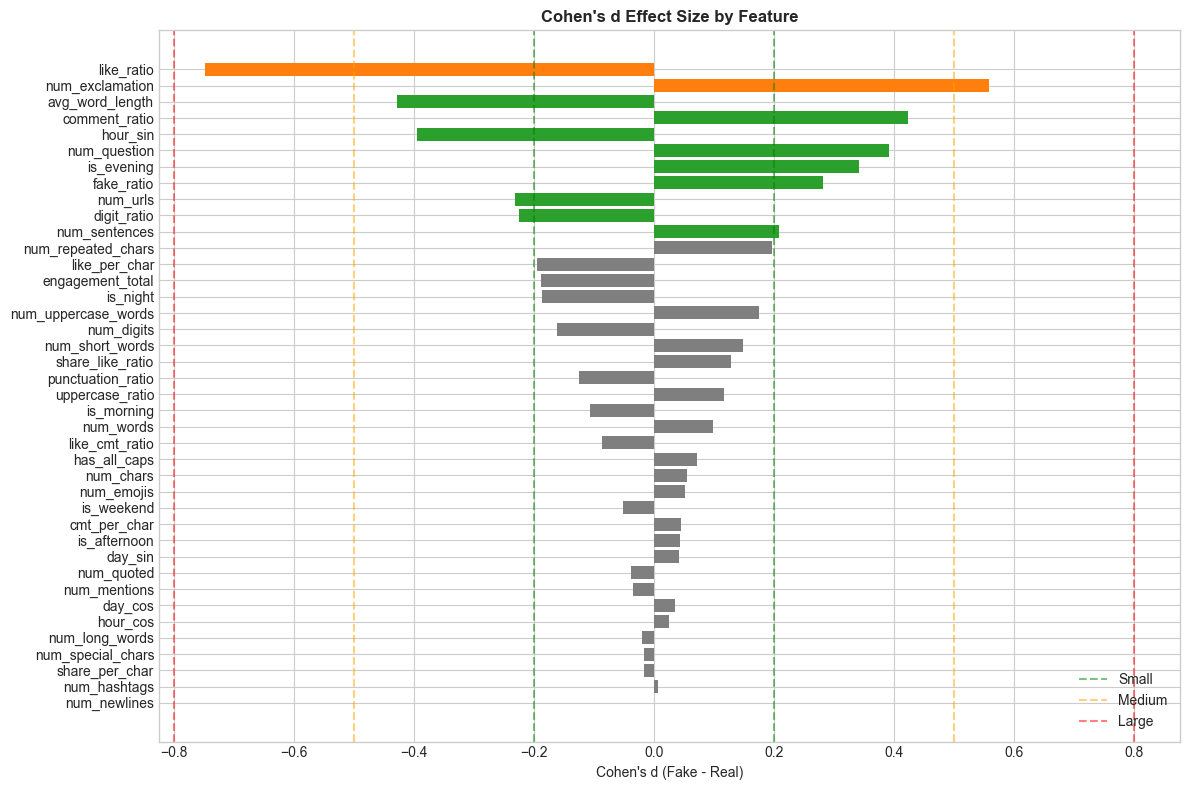

In [25]:
# Cohen's d bar chart
fig, ax = plt.subplots(figsize=(12, 8))

plot_df = results_df.sort_values('cohens_d_abs', ascending=True)
colors = ['#d62728' if d >= 0.8 else '#ff7f0e' if d >= 0.5 else '#2ca02c' if d >= 0.2 else '#7f7f7f' 
          for d in plot_df['cohens_d_abs']]

ax.barh(plot_df['feature'].str.replace('feat_', ''), plot_df['cohens_d'], color=colors)
ax.axvline(x=0.2, color='green', linestyle='--', alpha=0.5, label='Small')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large')
ax.axvline(x=-0.2, color='green', linestyle='--', alpha=0.5)
ax.axvline(x=-0.5, color='orange', linestyle='--', alpha=0.5)
ax.axvline(x=-0.8, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel("Cohen's d (Fake - Real)")
ax.set_title("Cohen's d Effect Size by Feature", fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'cohens_d_chart.png', dpi=150, bbox_inches='tight')
plt.show()

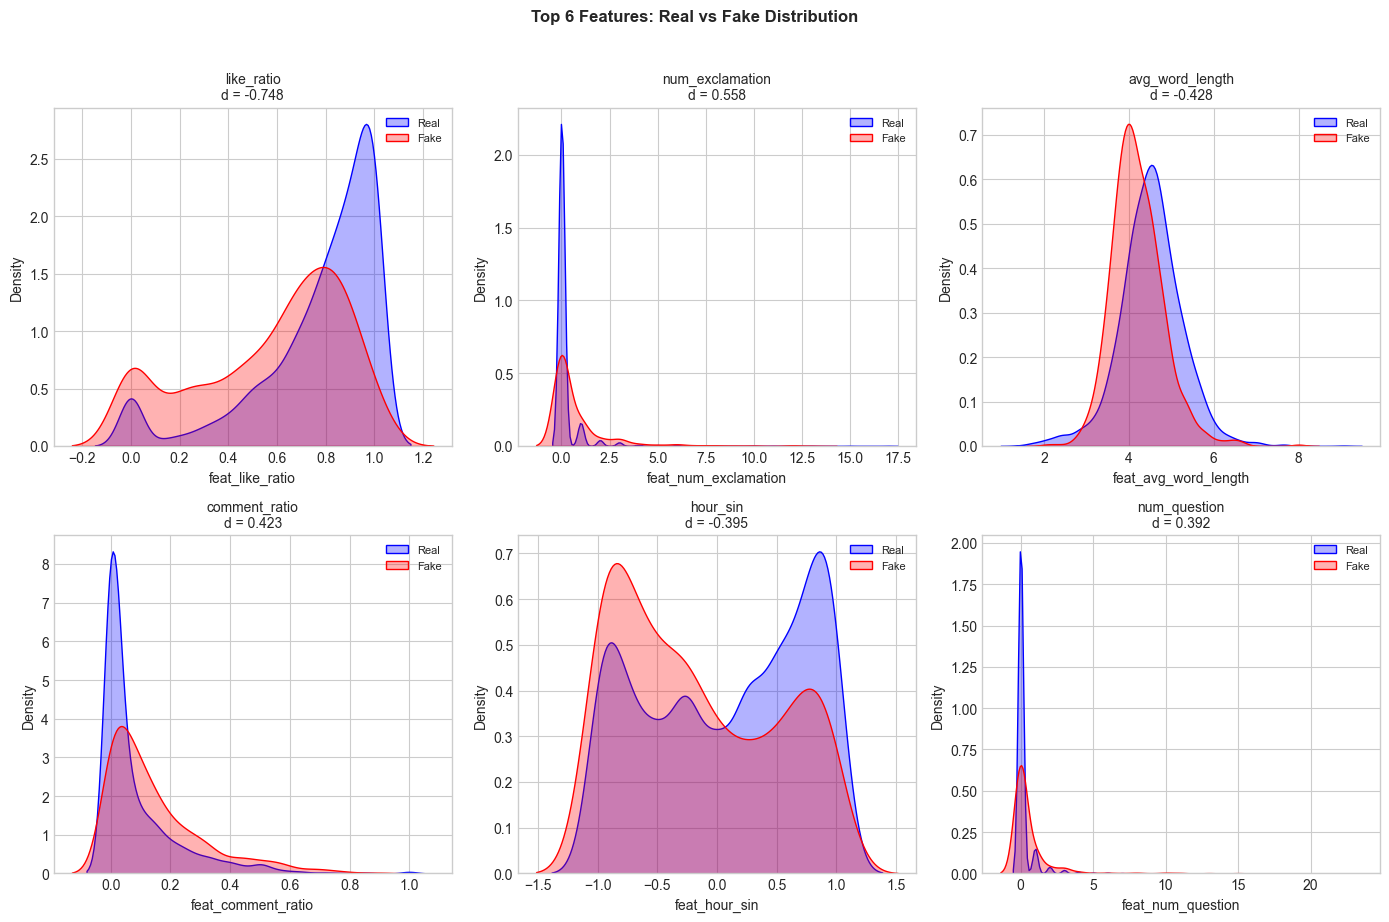

In [26]:
# Top features distribution
top_features = results_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    ax = axes[idx]
    sns.kdeplot(data=df_real[feat], ax=ax, label='Real', color='blue', fill=True, alpha=0.3)
    sns.kdeplot(data=df_fake[feat], ax=ax, label='Fake', color='red', fill=True, alpha=0.3)
    d = results_df[results_df['feature'] == feat]['cohens_d'].values[0]
    ax.set_title(f"{feat.replace('feat_', '')}\nd = {d:.3f}", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Top 6 Features: Real vs Fake Distribution", fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'top_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

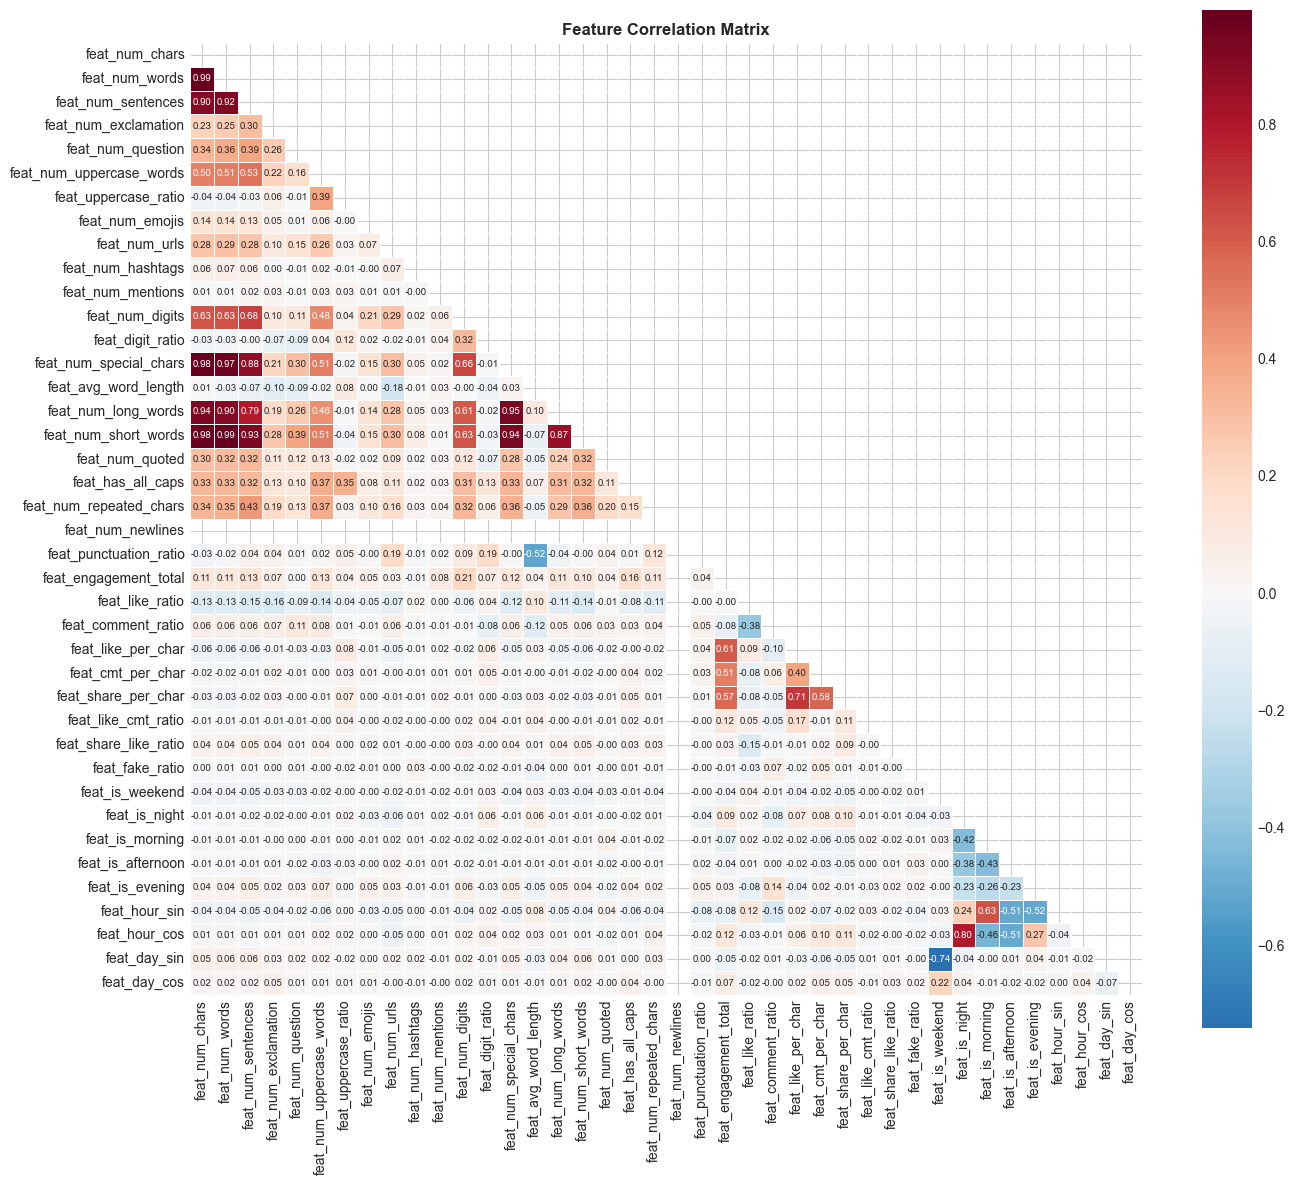

In [27]:
# Correlation heatmap
corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5, annot_kws={'size': 7})
ax.set_title("Feature Correlation Matrix", fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Selection Summary

In [28]:
# Selection criteria
COHENS_D_MIN = 0.2
P_VALUE_MAX = 0.05

selected = results_df[
    (results_df['cohens_d_abs'] >= COHENS_D_MIN) & 
    (results_df['t_pvalue'] < P_VALUE_MAX)
]

print(f"Selection criteria: |d| >= {COHENS_D_MIN}, p < {P_VALUE_MAX}")
print(f"\nSelected features: {len(selected)} / {len(results_df)}")
print("\n" + "="*60)
for _, row in selected.iterrows():
    print(f"  {row['feature']}: d={row['cohens_d']:.3f} ({row['effect_size']})")

Selection criteria: |d| >= 0.2, p < 0.05

Selected features: 11 / 40

  feat_like_ratio: d=-0.748 (medium)
  feat_num_exclamation: d=0.558 (medium)
  feat_avg_word_length: d=-0.428 (small)
  feat_comment_ratio: d=0.423 (small)
  feat_hour_sin: d=-0.395 (small)
  feat_num_question: d=0.392 (small)
  feat_is_evening: d=0.343 (small)
  feat_fake_ratio: d=0.282 (small)
  feat_num_urls: d=-0.231 (small)
  feat_digit_ratio: d=-0.225 (small)
  feat_num_sentences: d=0.208 (small)


In [29]:
# Save analysis results
results_df.to_csv(OUTPUT_ANALYSIS_DIR / 'feature_statistics.csv', index=False)
print(f"✓ Saved: {OUTPUT_ANALYSIS_DIR / 'feature_statistics.csv'}")

✓ Saved: ..\..\data\analysis\feature_statistics.csv


## 5. Data Leakage Check

Verify that user features are properly fixed

In [30]:
# Check feat_real_ratio and feat_fake_ratio
print("User Feature Statistics:")
print("="*50)

for feat in ['feat_real_ratio', 'feat_fake_ratio']:
    if feat in df.columns:
        print(f"\n{feat}:")
        print(f"  - Min: {df[feat].min():.4f}")
        print(f"  - Max: {df[feat].max():.4f}")
        print(f"  - Mean: {df[feat].mean():.4f}")
        print(f"  - Zero values: {(df[feat] == 0).sum()} ({(df[feat] == 0).mean()*100:.1f}%)")
        
        # Check Cohen's d for this feature
        d = results_df[results_df['feature'] == feat]['cohens_d'].values
        if len(d) > 0:
            print(f"  - Cohen's d: {d[0]:.4f}")

print("\n" + "="*50)
print("\nNote: High |Cohen's d| for user features after fix may indicate")
print("legitimate user behavior patterns (not data leakage).")

User Feature Statistics:

feat_fake_ratio:
  - Min: 0.0000
  - Max: 1.0000
  - Mean: 0.0144
  - Zero values: 4597 (97.1%)
  - Cohen's d: 0.2825


Note: High |Cohen's d| for user features after fix may indicate
legitimate user behavior patterns (not data leakage).
